In [98]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

## 환경

In [99]:
import sys, xgboost as xgb
print("Python:", sys.executable)
print("xgboost:", xgb.__version__)


Python: C:\Users\Admin\anaconda3\envs\ml-dl-nlp\python.exe
xgboost: 3.0.3


In [100]:
import xgboost as xgb
print(xgb.__version__)


3.0.3


In [101]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지


## 데이터 전처리

In [102]:
# 행의 범주 수정
import pandas as pd
from pathlib import Path

# ===== 경로 설정 =====
input_path  = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition.csv"
output_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv"

# ===== 데이터 불러오기 =====
df = pd.read_csv(input_path)

# ===== 매핑 정의 =====
travel_map = {
    'Travel_Rarely': '1~29회',
    'Travel_Frequently': '30회 이상',
    'Non-Travel': '0회'
}

major_map = {
    'Life Sciences': '사회과학계열',
    'Other': '기타',
    'Medical': '자연과학계열',
    'Marketing': '상경계열',
    'Technical Degree': '공학계열',
    'Human Resources': '인문학'
}

jobrole_map = {
    'Sales Executive': '영업직',
    'Research Scientist': '연구직',
    'Laboratory Technician': '엔지니어',
    'Manufacturing Director': '제조 책임자',
    'Healthcare Representative': '연구직 관리자',
    'Manager': '인사관리자',
    'Sales Representative': '영업 담당자',
    'Research Director': '연구 관리자',
    'Human Resources': '인사사원'
}

dept_map = {
    'Sales': '영업',
    'Research & Development': 'R&D',
    'Human Resources': '사무직'
}

# 숫자/문자 모두 대비
eval_map = {3: '보통', 4: '좋다', '3': '보통', '4': '좋다'}

# ===== 유틸: 후보 열 중 존재하는 첫 번째 열 찾기 =====
def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ===== 1) 출장 =====
src = pick_col(['출장', 'BusinessTravel'])
if src is not None:
    df['출장'] = df[src].replace(travel_map)

# ===== 2) 전공 =====
src = pick_col(['전공', 'EducationField'])
if src is not None:
    df['전공'] = df[src].replace(major_map)

# ===== 3) 직급 =====
src = pick_col(['직급', 'JobRole'])
if src is not None:
    df['직급'] = df[src].replace(jobrole_map)

# ===== 4) 부서 =====
src = pick_col(['부서', 'Department'])
if src is not None:
    df['부서'] = df[src].replace(dept_map)

# ===== 5) 업무평가 =====
# 보통 원본이 숫자 3/4 이지만, 문자열일 수도 있어 둘 다 매핑
src = pick_col(['업무평가', 'PerformanceRating'])
if src is not None:
    df['업무평가'] = df[src].replace(eval_map)

# ===== 저장 =====
Path(output_path).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False, encoding='utf-8-sig')

# ===== 확인용 출력 (존재하는 컬럼만 보여주기) =====
preview_cols = [c for c in ['출장', '전공', '직급', '부서', '업무평가'] if c in df.columns]
print("변환된 CSV 저장 완료:", output_path)
if preview_cols:
    print("\n[변환 결과 미리보기]")
    print(df[preview_cols].head().to_string(index=False))

변환된 CSV 저장 완료: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv

[변환 결과 미리보기]
    출장     전공   직급  부서 업무평가
 1~29회 사회과학계열  영업직  영업   보통
30회 이상 사회과학계열  연구직 R&D   좋다
 1~29회     기타 엔지니어 R&D   보통
30회 이상 사회과학계열  연구직 R&D   보통
 1~29회 자연과학계열 엔지니어 R&D   보통


In [103]:
import pandas as pd
import numpy as np

# 원본 CSV 경로
csv_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv"

# 변환된 CSV 저장 경로
save_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화.csv"

# 데이터 불러오기
try:
    df = pd.read_csv(csv_path)
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="cp949")

# 환율
USD_TO_KRW = 1350

# 급여 관련 컬럼 자동 탐색 (대소문자 무시)
# 일당, 시급 키워드까지 포함
keywords = ["월급", "연봉", "income", "salary", "급여", "일당", "시급"]
salary_cols = [col for col in df.columns 
               if any(k in col.lower() for k in keywords)]

# 원화 변환 적용
for c in salary_cols:
    if np.issubdtype(df[c].dtype, np.number):
        df[c] = df[c] * USD_TO_KRW
        print(f"[단위 변환] {c}: USD → 원화(KRW) 변환 완료")

# 변환된 데이터 저장
df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"✅ 변환 완료! 저장 위치: {save_path}")


[단위 변환] 월급: USD → 원화(KRW) 변환 완료
✅ 변환 완료! 저장 위치: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화.csv


## feature 값 변환

In [104]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# ===== 설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화.csv"
TARGET_COL = "업무평가"
ID_COLS = ["사번"]
TOP_N = 15

# ===== 1) 로드 =====
try:
    df = pd.read_csv(INPUT_CSV)
except UnicodeDecodeError:
    df = pd.read_csv(INPUT_CSV, encoding="cp949")

# ===== (A) 급여 USD -> KRW 변환(중복 방지) =====
USD_TO_KRW = 1350
# 시급/일당도 포함해서 모두 환율 판단
salary_keywords = ["월급", "연봉", "income", "salary", "급여", "시급", "일당"]
salary_cols = [c for c in df.columns if any(k in c.lower() for k in salary_keywords)]

for c in salary_cols:
    if np.issubdtype(df[c].dtype, np.number):
        med = float(pd.Series(df[c]).median())
        # 휴리스틱: 중앙값이 100,000 미만이면 USD로 보고 KRW 변환
        if med < 100_000:
            df[c] = df[c] * USD_TO_KRW
            print(f"[단위 변환] {c}: USD -> KRW 적용(median={med:.1f})")
        else:
            print(f"[단위 변환 건너뜀] {c}: 이미 KRW로 추정(median={med:.1f})")

# ===== (B) '일당' & '근무기준시간' 보강 =====
df_feat = df.copy()

# 근무일수 추정값(없으면 22일 가정)
if "근무일수" in df_feat.columns and np.issubdtype(df_feat["근무일수"].dtype, np.number):
    workdays = df_feat["근무일수"].replace(0, np.nan).fillna(22)
else:
    workdays = pd.Series(22, index=df_feat.index)
    print("[참고] '근무일수' 컬럼이 없어 22일로 가정합니다.")

# 일당 생성: (1) 월급 기준 (2) 월급 없으면 연봉/12
if "일당" not in df_feat.columns or not np.issubdtype(df_feat["일당"].dtype, np.number):
    new_daily = None
    if "월급" in df_feat.columns and np.issubdtype(df_feat["월급"].dtype, np.number):
        new_daily = df_feat["월급"] / workdays.clip(lower=1)  # 0분모 방지
        df_feat["일당"] = new_daily
        print("[파생변수] '일당'을 '월급/근무일수'로 생성했습니다.")
    elif "연봉" in df_feat.columns and np.issubdtype(df_feat["연봉"].dtype, np.number):
        new_daily = (df_feat["연봉"] / 12) / workdays.clip(lower=1)
        df_feat["일당"] = new_daily
        print("[파생변수] '일당'을 '연봉/12/근무일수'로 생성했습니다.")
    else:
        print("[경고] '월급' 또는 '연봉'이 없어 '일당'을 만들 수 없습니다. 이후 파생변수 일부가 건너뛰어질 수 있습니다.")

# 근무기준시간 생성: 근무일수*8 (없으면 22*8=176)
if "근무기준시간" not in df_feat.columns or not np.issubdtype(df_feat["근무기준시간"].dtype, np.number):
    df_feat["근무기준시간"] = workdays.clip(lower=1) * 8
    print("[파생변수] '근무기준시간'을 '근무일수*8'로 생성했습니다.")

# ===== 2) 파생피처 =====
def safe_ratio(new_col, num_col, den_col, add=0.5):
    """필요 컬럼 없으면 건너뛰고 경고, 있으면 생성"""
    if (num_col in df_feat.columns) and (den_col in df_feat.columns):
        if np.issubdtype(df_feat[num_col].dtype, np.number) and np.issubdtype(df_feat[den_col].dtype, np.number):
            df_feat[new_col] = df_feat[num_col] / (df_feat[den_col] + add)
            return True
    print(f"[건너뜀] '{new_col}' 계산: '{num_col}' 또는 '{den_col}' 가 없거나 수치형이 아님")
    return False

safe_ratio("프로젝트/경력",    "참여프로젝트", "경력")
safe_ratio("근속/경력",       "근속연차",     "경력")
safe_ratio("주변평가/프로젝트", "주변평가",     "참여프로젝트")
safe_ratio("월급/경력",       "월급",         "경력")
safe_ratio("월급/프로젝트",     "월급",         "참여프로젝트")
safe_ratio("프로젝트/교육출장",  "참여프로젝트", "전년도교육출장횟수")
safe_ratio("경력/나이",        "경력",         "나이")
safe_ratio("월급/워라밸",      "월급",         "워라밸")
safe_ratio("초과근무율",       "일당",         "근무기준시간")
safe_ratio("현근속/총근속",     "현회사근속년수", "근속연차")

# ===== 3) 학습/인코딩 =====
df_model = df_feat.drop(columns=[c for c in ID_COLS if c in df_feat.columns]).copy()

# 타깃/피처 분리 (타깃 누락 방지)
if TARGET_COL not in df_model.columns:
    raise KeyError(f"[오류] TARGET_COL='{TARGET_COL}' 컬럼이 없습니다. CSV의 컬럼명을 확인하세요.")

y = df_model[TARGET_COL]
X = df_model.drop(columns=[TARGET_COL])

# 문자열 컬럼 라벨 인코딩
X_enc = X.copy()
for col in X_enc.select_dtypes(include=["object"]).columns:
    X_enc[col] = LabelEncoder().fit_transform(X_enc[col].astype(str))
y_enc = LabelEncoder().fit_transform(y.astype(str))

# ===== 4) 중요도 기반 TOP N =====
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_enc, y_enc)
imp = pd.Series(rf.feature_importances_, index=X_enc.columns).sort_values(ascending=False)
top_features = imp.head(TOP_N).index.tolist()
print("[선정된 상위 피처]", *top_features, sep="\n- ")

# ===== 5) 그 피처만 추출 + UTF-8(BOM) 하나만 저장 =====
selected_df = df_feat[top_features + [TARGET_COL]].copy()
base, ext = os.path.splitext(INPUT_CSV)
out_utf8 = base + f"_selected_top{TOP_N}_utf8.csv"
selected_df.to_csv(out_utf8, index=False, encoding="utf-8-sig")
print(f"\n저장 완료 ✅ UTF-8(BOM): {out_utf8}")


[단위 변환 건너뜀] 월급: 이미 KRW로 추정(median=6640650.0)
[참고] '근무일수' 컬럼이 없어 22일로 가정합니다.
[파생변수] '일당'을 '월급/근무일수'로 생성했습니다.
[선정된 상위 피처]
- 월급/경력
- 월급/워라밸
- 월급/프로젝트
- 경력/나이
- 월급
- 거리
- 일당
- 초과근무율
- 나이
- 프로젝트/경력
- 근속/경력
- 현근속/총근속
- 프로젝트/교육출장
- 현회사근속년수
- 주변평가/프로젝트

저장 완료 ✅ UTF-8(BOM): C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화_selected_top15_utf8.csv


In [105]:
import pandas as pd

CSV_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화_selected_top15_utf8.csv"

# CP949 또는 EUC-KR 시도
df = pd.read_csv(CSV_PATH, encoding='utf8')
# df = pd.read_csv(CSV_PATH, encoding='euc-kr')

print(df.head())


           월급/경력        월급/워라밸       월급/프로젝트     경력/나이       월급  거리  \
0  951829.411765  5.393700e+06  2.311586e+06  0.192771  8090550   1   
1  659571.428571  1.978714e+06  2.770200e+06  0.202020  6925500   8   
2  376200.000000  8.061429e+05  1.128600e+06  0.186667  2821500   2   
3  462017.647059  1.122043e+06  1.122043e+06  0.238806  3927150   3   
4  720276.923077  1.337657e+06  1.337657e+06  0.218182  4681800   2   

              일당        초과근무율  나이   프로젝트/경력     근속/경력   현근속/총근속  프로젝트/교육출장  \
0  367752.272727  4568.351214  41  0.352941  0.235294  2.400000   6.000000   
1  314795.454545  3910.502541  49  0.190476  0.190476  4.000000   0.571429   
2  128250.000000  1593.167702  37  0.266667  0.133333  0.000000   0.571429   
3  178506.818182  2217.476002  33  0.352941  0.117647  5.333333   0.857143   
4  212809.090909  2643.591191  27  0.461538  0.153846  1.333333   0.857143   

   현회사근속년수  주변평가/프로젝트 업무평가  
0        6   0.285714   보통  
1       10   1.600000   좋다  
2        0   0.80

## 데이터 상관관계 및 Feature Importance

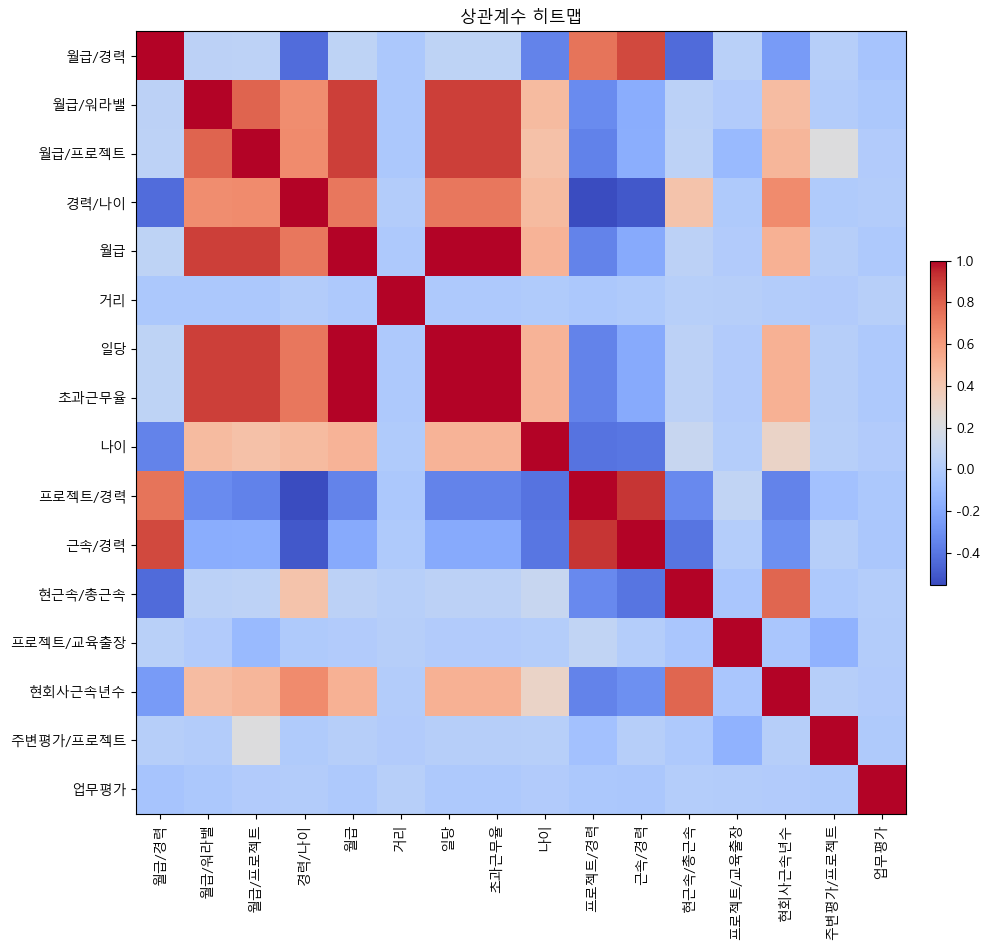

<Figure size 640x480 with 0 Axes>

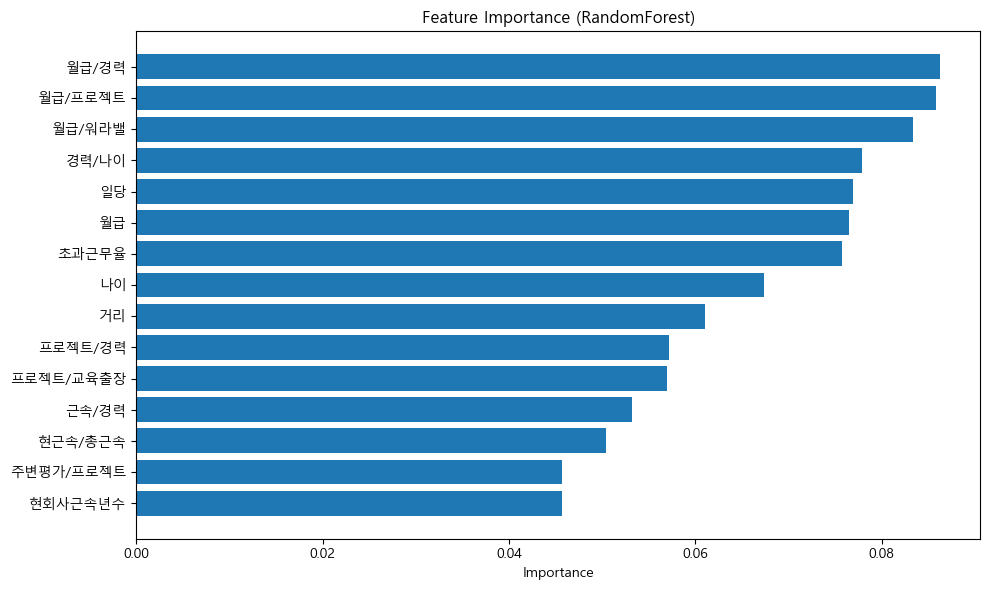

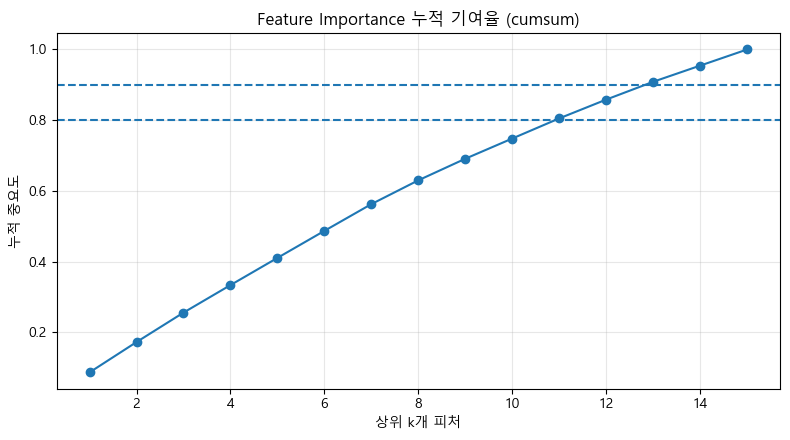

==== 저장 완료 ====
히트맵 : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs\corr_heatmap.png
도트플롯 : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs\corr_dotplot.png
FI Bar  : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs\feature_importance_bar.png
FI Cum  : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs\feature_importance_cumsum.png
Top CSV : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs\top_features.csv


In [106]:
# -*- coding: utf-8 -*-
"""
인사평가 ML - 상관계수 & Feature Importance 최종 코드
- 입력 : CSV (인코딩 자동 판별)
- 타깃 : '업무평가' (문자면 {'보통':0,'좋다':1} 매핑)
- 출력 :
  1) corr_heatmap.png
  2) corr_dotplot.png
  3) feature_importance_bar.png
  4) feature_importance_cumsum.png
  5) top_features.csv
"""

import os
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------------------
# 0) 경로 설정 
# ---------------------------------------------------------------------

DATA_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화_selected_top15_utf8.csv"
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\insaml_outputs"
os.makedirs(OUTDIR, exist_ok=True)

CORR_HEAT_PNG = os.path.join(OUTDIR, "corr_heatmap.png")
CORR_DOT_PNG  = os.path.join(OUTDIR, "corr_dotplot.png")
FI_BAR_PNG    = os.path.join(OUTDIR, "feature_importance_bar.png")
FI_CUM_PNG    = os.path.join(OUTDIR, "feature_importance_cumsum.png")
TOPCSV        = os.path.join(OUTDIR, "top_features.csv")

# ---------------------------------------------------------------------
# 1) 한글 폰트 설정 (환경별 자동 선택)
# ---------------------------------------------------------------------
def set_korean_font():
    system = platform.system().lower()
    if 'windows' in system:
        plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
    elif 'darwin' in system or 'mac' in system:
        plt.rcParams['font.family'] = 'AppleGothic'    # macOS
    else:
        # 리눅스의 경우 나눔고딕이 설치되어 있어야 함
        plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ---------------------------------------------------------------------
# 2) 데이터 로드 (인코딩 자동 시도)
# ---------------------------------------------------------------------
df = None
for enc in ["cp949", "euc-kr", "utf-8-sig", "utf-8"]:
    try:
        df = pd.read_csv(DATA_PATH, encoding=enc)
        break
    except Exception:
        continue
if df is None:
    raise RuntimeError("CSV 인코딩을 판별하지 못했습니다. 파일 인코딩을 확인해주세요.")

# ---------------------------------------------------------------------
# 3) 타깃 준비
# ---------------------------------------------------------------------
target_col = "업무평가"
if target_col not in df.columns:
    raise ValueError(f"타깃 컬럼 '{target_col}'이 없습니다. 실제 컬럼: {list(df.columns)}")

y = df[target_col].copy()
if y.dtype == "object":
    mapping = {"보통": 0, "좋다": 1, "나쁨": 0, "나쁘다": 0}
    y = y.map(lambda v: mapping.get(v, v))
if not np.issubdtype(y.dtype, np.number):
    y = pd.Categorical(y).codes

# ---------------------------------------------------------------------
# 4) 피처 준비 (범주형 → 원핫)
# ---------------------------------------------------------------------
X = df.drop(columns=[target_col])
cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# ---------------------------------------------------------------------
# 5) Train/Test 분리 & RandomForest 학습
# ---------------------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

# ---------------------------------------------------------------------
# 6) 상관계수 계산 (수치형 + 타깃 함께)
# ---------------------------------------------------------------------
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
corr_df = df[num_cols].copy()
corr_df[target_col] = y.values
corr = corr_df.corr(numeric_only=True)

#  히트맵 (matplotlib만 사용)
plt.figure(figsize=(max(10, len(corr.columns)*0.6), max(8, len(corr.index)*0.6)))
plt.imshow(corr, aspect="auto", cmap="coolwarm")
plt.title("상관계수 히트맵")
plt.colorbar(fraction=0.02, pad=0.03)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)),   corr.index)
plt.tight_layout()
plt.savefig(CORR_HEAT_PNG, dpi=160)
plt.show()


scale = 600  # 점 크기 스케일 (필요 시 조정)
for i in range(n):
    for j in range(n):
        r = float(corr.iat[i, j])
        s = (abs(r) * scale)
        ax.scatter(j, i, s=s)  # 색상 지정 X (기본값)
        ax.text(j, i, f"{r:.2f}", ha='center', va='center', fontsize=8)

ax.set_title("상관관계 도트 플롯 (점 크기 = |상관계수|)")
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.savefig(CORR_DOT_PNG, dpi=160)
plt.show()

# ---------------------------------------------------------------------
# 7) Feature Importance 시각화 + cumsum
# ---------------------------------------------------------------------
fi = rf.feature_importances_
fi_idx = np.argsort(fi)[::-1]
fi_sorted = fi[fi_idx]
fi_names  = X_tr.columns[fi_idx]

# 상위 중요 피처 CSV
N = min(50, len(fi_names))
pd.DataFrame({"feature": fi_names[:N], "importance": fi_sorted[:N]}) \
  .to_csv(TOPCSV, index=False, encoding="utf-8-sig")

# (a) 막대 그래프
plt.figure(figsize=(10, max(4, int(len(fi_sorted) * 0.4))))
plt.barh(range(len(fi_sorted)), fi_sorted[::-1])
plt.yticks(range(len(fi_sorted)), fi_names[::-1])
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FI_BAR_PNG, dpi=160)
plt.show()

# (b) 누적합(cumsum)
fi_cum = np.cumsum(fi_sorted)
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(fi_cum) + 1), fi_cum, marker="o")
plt.axhline(0.8, linestyle="--")  # 80% 라인
plt.axhline(0.9, linestyle="--")  # 90% 라인
plt.title("Feature Importance 누적 기여율 (cumsum)")
plt.xlabel("상위 k개 피처")
plt.ylabel("누적 중요도")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FI_CUM_PNG, dpi=160)
plt.show()

print("==== 저장 완료 ====")
print("히트맵 :", CORR_HEAT_PNG)
print("도트플롯 :", CORR_DOT_PNG)
print("FI Bar  :", FI_BAR_PNG)
print("FI Cum  :", FI_CUM_PNG)
print("Top CSV :", TOPCSV)


## 인사평가 이진분류 - 최종 코드 (XGBoost 3.x)

### 0) 데이터로드 & 타켓매핑

In [107]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import xgboost as xgb

CSV_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환_원화_selected_top15_utf8.csv"

# 인코딩 자동 시도(utf-8 → cp949)
try:
    df = pd.read_csv(CSV_PATH)
except UnicodeDecodeError:
    df = pd.read_csv(CSV_PATH, encoding="cp949")

TARGET_COL = "업무평가"
if TARGET_COL not in df.columns:
    raise ValueError(f"타깃 컬럼 '{TARGET_COL}' 이(가) 데이터에 없습니다. 실제 컬럼명을 확인해주세요.")

# 이진 타깃 매핑 (보통=0, 좋다=1) — 이미 숫자면 그대로 사용
if df[TARGET_COL].dtype == "O":
    bin_map = {"보통": 0, "좋다": 1}
    df[TARGET_COL] = df[TARGET_COL].map(bin_map).astype(int)



### 1) 피처& 타깃 분리, 데이터 분할 및 전처리 파이프라인

In [108]:
# -------------------------
# 피처& 타깃 분리
# -------------------------
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

# 숫자/범주형 자동 식별
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number, "float64", "int64", "int32", "float32"]).columns.tolist()

print(f"📊 피처: {X.shape[1]} | 숫자형: {len(num_cols)} | 범주형: {len(cat_cols)}")

# -------------------------
# 데이터 분할 (train/val/test)
# -------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# -------------------------
# 전처리 파이프라인
# -------------------------
num_tf = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# sklearn 버전 호환: sparse_output 지원 없으면 sparse 사용
try:
    cat_tf = Pipeline(steps=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    cat_tf = Pipeline(steps=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, num_cols),
        ("cat", cat_tf, cat_cols)
    ],
    remainder="drop"
)



📊 피처: 15 | 숫자형: 15 | 범주형: 0


### 2) 클래스 불균형 보정, 전처리 적합 및 변환

In [109]:
# -------------------------
#  클래스 불균형 보정 (scale_pos_weight)
# -------------------------
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = max(1.0, neg / max(1, pos))
print(f" scale_pos_weight(자동): {scale_pos_weight:.2f}")

# -------------------------
# 전처리 적합 & 변환
# -------------------------
prep = preprocess.fit(X_train, y_train)
X_train_t = prep.transform(X_train)
X_val_t   = prep.transform(X_val)
X_test_t  = prep.transform(X_test)

# 변환 후 피처 이름 생성
num_feature_names = num_cols
if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["ohe"]
    # get_feature_names_out 지원/미지원 호환
    try:
        cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    except AttributeError:
        # 구버전 스케치: 카테고리 조합명 대신 단순 열 번호 부여
        cat_feature_names = []
        start = len(num_feature_names)
        for i in range(ohe.transform(pd.DataFrame({c: X_train[c] for c in cat_cols})).shape[1]):
            cat_feature_names.append(f"cat_{i}")
else:
    cat_feature_names = []
all_feature_names = num_feature_names + cat_feature_names



 scale_pos_weight(자동): 5.51


### 3) XGBoost 학습

In [110]:

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,                 # reg_lambda
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train_t, label=y_train, feature_names=all_feature_names)
dval   = xgb.DMatrix(X_val_t,   label=y_val,   feature_names=all_feature_names)
dtest  = xgb.DMatrix(X_test_t,  label=y_test,  feature_names=all_feature_names)

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=[(dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=False
)

best_iter = getattr(bst, "best_iteration", None)
if best_iter is None:
    # 일부 버전은 best_ntree_limit만 제공
    best_iter = bst.best_ntree_limit - 1

# -------------------------
#  임계값 최적화(정확도 기준) + 테스트 평가
# -------------------------
val_proba = bst.predict(dval, iteration_range=(0, best_iter + 1))
grid = np.linspace(0.2, 0.8, 61)
best_thr, best_acc = 0.5, -1.0
for t in grid:
    pred = (val_proba >= t).astype(int)
    acc = accuracy_score(y_val, pred)
    if acc > best_acc:
        best_thr, best_acc = t, acc
print(f"\n=== Validation (임계값 탐색) ===")
print(f"best_thr={best_thr:.3f} | best_accuracy={best_acc:.4f}")

test_proba = bst.predict(dtest, iteration_range=(0, best_iter + 1))
test_pred  = (test_proba >= best_thr).astype(int)

acc  = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, test_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, test_pred, average="weighted", zero_division=0)

print("\n=== Test (최적 임계값 적용) ===")
print(f"- accuracy          : {acc:.4f}")
print(f"- precision_weighted: {prec:.4f}")
print(f"- recall_weighted   : {rec:.4f}")
print(f"- f1_weighted       : {f1:.4f}")

print("\n[Classification Report - Test]")
print(classification_report(y_test, test_pred, digits=4, target_names=["보통(0)", "좋다(1)"]))

cm = confusion_matrix(y_test, test_pred)
print("\n[Confusion Matrix - Test]")
print(cm)


# -------------------------
# 단건 예측 유틸 (입력 딕셔너리 → 전처리 → DMatrix → 예측)
# -------------------------
def predict_one(sample_dict: dict, threshold: float | None = None):
    """
    sample_dict: {컬럼명: 값} (원본 데이터 컬럼명 기준, 범주형은 원래 라벨로 입력)
    threshold: None이면 best_thr 사용
    반환: {"proba_1": float, "threshold": float, "pred": int(0/1)}
    """
    # 1) 순서 정렬 및 누락 컬럼 채움
    x_one = pd.DataFrame([sample_dict])
    # 누락된 컬럼은 NaN → 전처리 파이프라인이 처리
    for col in X.columns:
        if col not in x_one.columns:
            x_one[col] = np.nan
    x_one = x_one[X.columns]  # 열 순서 맞춤

    # 2) 동일 전처리 적용
    x_one_t = prep.transform(x_one)

    # 3) DMatrix 변환 (같은 feature_names)
    done = xgb.DMatrix(x_one_t, feature_names=all_feature_names)

    # 4) 예측
    proba = float(bst.predict(done, iteration_range=(0, best_iter + 1))[0])
    thr = float(best_thr if threshold is None else threshold)
    pred = int(proba >= thr)
    return {"proba_1": proba, "threshold": thr, "pred": pred}




=== Validation (임계값 탐색) ===
best_thr=0.620 | best_accuracy=0.8455

=== Test (최적 임계값 적용) ===
- accuracy          : 0.8462
- precision_weighted: 0.7983
- recall_weighted   : 0.8462
- f1_weighted       : 0.7911

[Classification Report - Test]
              precision    recall  f1-score   support

       보통(0)     0.8525    0.9893    0.9158       187
       좋다(1)     0.5000    0.0588    0.1053        34

    accuracy                         0.8462       221
   macro avg     0.6763    0.5241    0.5106       221
weighted avg     0.7983    0.8462    0.7911       221


[Confusion Matrix - Test]
[[185   2]
 [ 32   2]]


### 4) 결과값 넣기

In [111]:
import joblib
from xgboost import XGBClassifier

# 1) 모델 학습
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb_clf.fit(X_train, y_train)  # ← 반드시 학습

# 2) feature_names 저장
feature_names = X_train.columns.tolist()

# 3) 라벨 매핑
label_map = {0: '보통', 1: '좋음'}

# 4) 번들 구성
bundle = {
    "model": xgb_clf,            # 학습된 XGBoost 모델 객체
    "feature_names": feature_names,
    "label_map": label_map
}

# 5) 저장
joblib.dump(bundle, "xgb_bundle.pkl")
print("학습 완료된 모델을 xgb_bundle.pkl로 저장했습니다.")


학습 완료된 모델을 xgb_bundle.pkl로 저장했습니다.


In [112]:
import joblib
import numpy as np

# ==== 번들 로드 ====
def load_bundle(path="xgb_bundle.pkl"):
    bundle = joblib.load(path)
    return bundle["model"], bundle["feature_names"], bundle["label_map"]

def _input_float(prompt, default=None):
    """기본값 지원 입력 (Enter 시 기본값 사용)"""
    if default is None:
        return float(input(prompt))
    s = input(f"{prompt} [기본 {default}]: ").strip()
    return float(s) if s else float(default)

# ==== 예측 함수 ====
def predict_from_inputs(bundle_path="xgb_bundle.pkl"):
    model, feat_names, label_map = load_bundle(bundle_path)

    # 1) 사용자 입력 (원시 변수)
    월급 = _input_float("월급 입력(원화): ")
    경력 = _input_float("경력(년) 입력: ")
    나이 = _input_float("나이 입력: ")
    프로젝트 = _input_float("프로젝트 수 입력: ")
    워라밸 = _input_float("워라밸 점수 입력 (1~5점, 1=나쁨, 5=좋음): ")
    워라밸 = min(max(워라밸, 1.0), 5.0)  # 범위 제한
    거리 = _input_float("거리(km) 입력: ")
    현근속 = _input_float("현회사 근속년수 입력: ")
    총근속 = _input_float("총 근속연수 입력 (지금 회사 포함, 이전 회사 경력 모두 합계 연수): ")
    교육출장 = _input_float("교육/출장 횟수 입력: ")

    # '주변평가/프로젝트'가 있으면 입력
    주변평가 = None
    if "주변평가/프로젝트" in feat_names:
        주변평가 = _input_float("주변평가 입력 (1~5 등급): ")

    # 근무일수 / 하루근무시간
    근무일수 = _input_float("한 달 근무일수 입력: ", default=22)
    하루근무시간 = _input_float("하루 근무시간(시간) 입력: ", default=8)

    # 2) 파생 변수 계산
    일당 = 월급 / 근무일수 if 근무일수 > 0 else 0.0
    시급 = 일당 / 하루근무시간 if 하루근무시간 > 0 else 0.0
    근무기준시간 = 근무일수 * 8

    # 초과근무율 자동 계산 (학습 동일)
    초과근무율 = 일당 / (근무기준시간 + 0.5) if 근무기준시간 > 0 else 0.0

    월급_경력 = 월급 / 경력 if 경력 != 0 else 0.0
    월급_프로젝트 = 월급 / 프로젝트 if 프로젝트 != 0 else 0.0
    월급_워라밸 = 월급 / 워라밸 if 워라밸 != 0 else 0.0
    경력_나이 = 경력 / 나이 if 나이 != 0 else 0.0
    프로젝트_경력 = 프로젝트 / 경력 if 경력 != 0 else 0.0
    현근속_총근속 = 현근속 / 총근속 if 총근속 != 0 else 0.0
    근속_경력 = 총근속 / 경력 if 경력 != 0 else 0.0
    프로젝트_교육출장 = 프로젝트 / 교육출장 if 교육출장 != 0 else 0.0

    # 3) feature_names 매핑
    feat_map = {
        "월급/경력": 월급_경력,
        "시급": 시급,
        "월급/프로젝트": 월급_프로젝트,
        "월급": 월급,
        "월급/워라밸": 월급_워라밸,
        "일당": 일당,
        "초과근무율": 초과근무율,
        "경력/나이": 경력_나이,
        "나이": 나이,
        "거리": 거리,
        "프로젝트/경력": 프로젝트_경력,
        "현근속/총근속": 현근속_총근속,
        "근속/경력": 근속_경력,
        "프로젝트/교육출장": 프로젝트_교육출장,
        "현회사근속년수": 현근속,
    }
    if "주변평가/프로젝트" in feat_names and 주변평가 is not None:
        feat_map["주변평가/프로젝트"] = 주변평가 / max(프로젝트, 1)

    # 누락 피처 확인
    missing = [f for f in feat_names if f not in feat_map]
    if missing:
        print("[경고] 계산되지 않은 피처가 있어 0으로 대체합니다:", missing)

    X_input = np.array([feat_map.get(f, 0.0) for f in feat_names]).reshape(1, -1)

    # 4) 예측
    pred_class = int(model.predict(X_input)[0])
    p_good = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_input)[0]
        if len(proba) == 2:
            p_good = float(proba[1])

    # 5) 결과
    print("\n=== 예측 결과 ===")
    print(f"업무평가 예측: {label_map.get(pred_class, pred_class)}")
    if p_good is not None:
        print(f"'좋음' 확률: {p_good:.4f}")

# ==== 실행 ====
if __name__ == "__main__":
    predict_from_inputs("xgb_bundle.pkl")


KeyboardInterrupt: Interrupted by user